Mounted at /content/drive
Extracting dataset...
Done.
Path to dataset files: /content/cifake_dataset


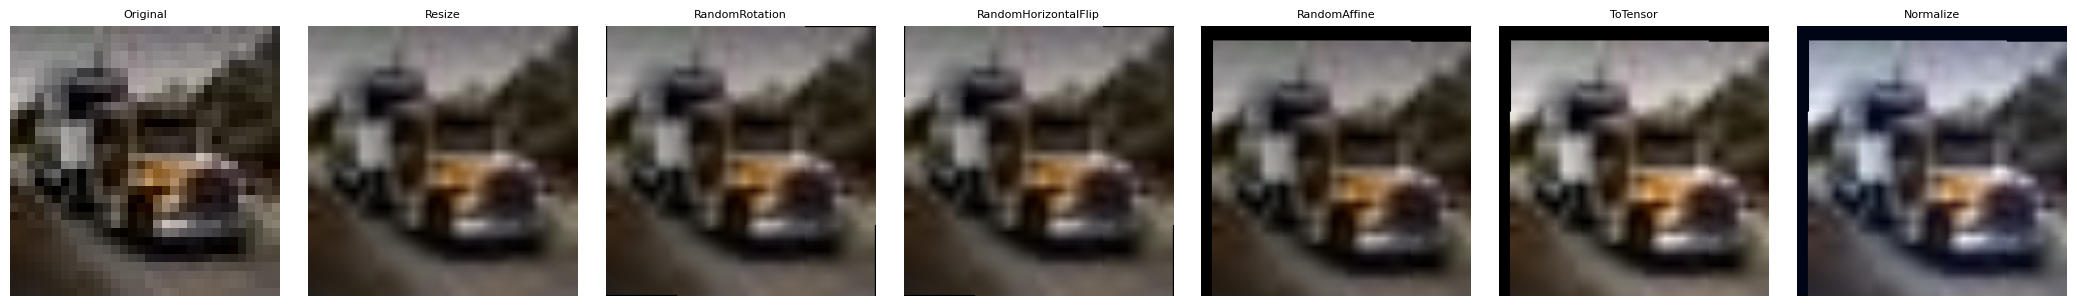

Classes: {'FAKE': 0, 'REAL': 1}
Training samples: 99000, Validation samples: 11000, Test samples: 20000
FAKE: 60000, REAL: 50000, pos_weight: 1.200
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 169MB/s]



Total parameters: 24,066,369
Trainable parameters: 558,337


In [1]:
#import all necessary libraries
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from PIL import Image

# Configuration
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS_PHASE1 = 15  # Head-only training: converges faster with frozen ImageNet backbone
EPOCHS_PHASE2 = 25  # Fine-tuning: slow updates at low lr benefit from full budget
DEVICE = torch.device("cuda")

# Augmented Dataset is loaded from Google Drive
from google.colab import drive
drive.mount("/content/drive", force_remount=False)

# Extract dataset from zip
zip_path = "/content/drive/MyDrive/Dissertation/cifake_dataset.zip"
extract_to = "/content/cifake_dataset"
if not os.path.exists(extract_to):
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall("/content")
    print("Done.")
DATASET_DIR = extract_to
print("Path to dataset files:", DATASET_DIR)

# Data Loading
# CIFAKE dataset structure:
#   train/REAL/, train/FAKE/
#   test/REAL/, test/FAKE/

train_dir = os.path.join(DATASET_DIR, "train")
test_dir = os.path.join(DATASET_DIR, "test")

# Preprocessing & Data Augmentation
# ResNet50 expects ImageNet normalization
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    # Data Augmentation (applied only to training images)
    transforms.RandomRotation(10),             # Randomly rotate images up to 10 degrees
    transforms.RandomHorizontalFlip(),         # Randomly mirror images horizontally
    transforms.RandomAffine(                   # Random translation
        degrees=0,
        translate=(0.1, 0.1),                  # Shift up to 10% horizontally/vertically
    ),
    # Preprocessing
    transforms.ToTensor(),                     # Convert to tensor and scale to [0, 1]
    transforms.Normalize(                      # ImageNet normalization for pretrained ResNet50
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

# Preprocessing only, no augmentation applied to test data
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

# visualize Augmentation Pipeline

def to_displayable(img):
    if isinstance(img, Image.Image):
        return np.array(img) / 255.0
    arr = img.permute(1, 2, 0).numpy()
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)


sample_path = datasets.ImageFolder(train_dir).samples[0][0]
raw_img = Image.open(sample_path).convert("RGB")

pipeline_steps = [("Original", raw_img)]
current = raw_img
for t in train_transform.transforms:
    current = t(current)
    pipeline_steps.append((type(t).__name__, current))

fig, axes = plt.subplots(1, len(pipeline_steps), figsize=(3 * len(pipeline_steps), 3))
for ax, (name, img) in zip(axes, pipeline_steps):
    ax.imshow(to_displayable(img))
    ax.set_title(name, fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.savefig("resnet50_augmentation_pipeline.png", dpi=150)
plt.show()

# Load datasets
full_train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
# Separate, untransformed copy so the validation split isn't randomly augmented each epoch
full_train_dataset_eval = datasets.ImageFolder(train_dir, transform=test_transform)

# Reserve 10% of training data for validation
val_size = int(0.1 * len(full_train_dataset))
train_size = len(full_train_dataset) - val_size
train_indices, val_indices = random_split(range(len(full_train_dataset)), [train_size, val_size])
train_dataset = Subset(full_train_dataset, train_indices.indices)
val_dataset = Subset(full_train_dataset_eval, val_indices.indices)

test_dataset = datasets.ImageFolder(test_dir, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Classes: {full_train_dataset.class_to_idx}")
print(f"Training samples: {train_size}, Validation samples: {val_size}, Test samples: {len(test_dataset)}")

# GAN augmentation adds images to FAKE only, skewing the class balance.
# Compute pos_weight from the actual counts rather than hardcoding a ratio
class_counts = np.bincount([label for _, label in full_train_dataset.samples])
fake_count, real_count = class_counts[0], class_counts[1]
pos_weight = torch.tensor([fake_count / real_count], device=DEVICE)
print(f"FAKE: {fake_count}, REAL: {real_count}, pos_weight: {pos_weight.item():.3f}")


# ResNet50 Transfer Learning Model
base_model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

# Freeze the base model layers
for param in base_model.parameters():
    param.requires_grad = False

# Replace the final fully connected layer with custom classification head
num_features = base_model.fc.in_features
base_model.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.BatchNorm1d(256),
    nn.Dropout(0.5),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.BatchNorm1d(128),
    nn.Dropout(0.3),
    nn.Linear(128, 1),
)

model = base_model.to(DEVICE)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Training Setup
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Checkpoints to train model in phases due to colab usage limitations.
save_dir = "/content/drive/MyDrive/Dissertation"
os.makedirs(save_dir, exist_ok=True)
phase1_checkpoint_path = os.path.join(save_dir, "cifake_resnet50_phase1_checkpoint.pth")
phase2_checkpoint_path = os.path.join(save_dir, "cifake_resnet50_phase2_checkpoint.pth")
patience = 5  # shared by all phases

def freeze_frozen_batchnorms(module):
    """model.train() puts every submodule into train mode regardless of
    requires_grad, so a 'frozen' backbone's BatchNorm2d layers still update
    their running_mean/running_var every step. Explicitly re-freeze (eval
    mode) any BatchNorm2d whose affine params aren't being trained — this
    naturally adapts across phases since it checks requires_grad live
    (all backbone BN in Phase 1, only layer1-3 BN once layer4 unfreezes).
    """
    for m in module.modules():
        if isinstance(m, nn.BatchNorm2d) and not m.weight.requires_grad:
            m.eval()


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    freeze_frozen_batchnorms(model)
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.float().to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images).squeeze(1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.float().to(DEVICE)
            outputs = model(images).squeeze(1)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total

In [ ]:
if os.path.exists(phase1_checkpoint_path):
    print(f"Phase 1 checkpoint already exists at {phase1_checkpoint_path} — skipping Phase 1")
else:
    # Phase 1: Train classification head (base frozen)
    print("\n=== Phase 1: Training classification head (base frozen) ===")
    optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3, min_lr=1e-6)

    history = {"accuracy": [], "val_accuracy": [], "loss": [], "val_loss": []}
    best_val_loss = float("inf")
    patience_counter = 0
    best_model_state = None

    for epoch in range(EPOCHS_PHASE1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        scheduler.step(val_loss)

        history["loss"].append(train_loss)
        history["accuracy"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_acc)

        current_lr = optimizer.param_groups[0]["lr"]
        print(f"Epoch {epoch+1}/{EPOCHS_PHASE1} - loss: {train_loss:.4f} - acc: {train_acc:.4f} "
              f"- val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f} - lr: {current_lr:.1e}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_state = model.state_dict().copy()
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\nEarly stopping at epoch {epoch+1}")
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    phase1_epochs = len(history["accuracy"])

    # Save Phase 1 checkpoint
    torch.save({
        "model_state_dict": model.state_dict(),
        "phase1_epochs": phase1_epochs,
        "history": history,
    }, phase1_checkpoint_path)
    print(f"Phase 1 checkpoint saved to {phase1_checkpoint_path}")


=== Phase 1: Training classification head (base frozen) ===
Epoch 1/15 - loss: 0.2684 - acc: 0.8992 - val_loss: 0.2055 - val_acc: 0.9268 - lr: 1.0e-03
Epoch 2/15 - loss: 0.2205 - acc: 0.9199 - val_loss: 0.1824 - val_acc: 0.9316 - lr: 1.0e-03
Epoch 3/15 - loss: 0.2082 - acc: 0.9236 - val_loss: 0.1680 - val_acc: 0.9415 - lr: 1.0e-03
Epoch 4/15 - loss: 0.1976 - acc: 0.9294 - val_loss: 0.1575 - val_acc: 0.9440 - lr: 1.0e-03
Epoch 5/15 - loss: 0.1892 - acc: 0.9327 - val_loss: 0.1563 - val_acc: 0.9453 - lr: 1.0e-03
Epoch 6/15 - loss: 0.1827 - acc: 0.9340 - val_loss: 0.1482 - val_acc: 0.9475 - lr: 1.0e-03
Epoch 7/15 - loss: 0.1771 - acc: 0.9381 - val_loss: 0.1423 - val_acc: 0.9502 - lr: 1.0e-03
Epoch 8/15 - loss: 0.1739 - acc: 0.9380 - val_loss: 0.1462 - val_acc: 0.9493 - lr: 1.0e-03
Epoch 9/15 - loss: 0.1708 - acc: 0.9395 - val_loss: 0.1426 - val_acc: 0.9503 - lr: 1.0e-03
Epoch 10/15 - loss: 0.1653 - acc: 0.9421 - val_loss: 0.1418 - val_acc: 0.9498 - lr: 1.0e-03
Epoch 11/15 - loss: 0.1611 -

In [ ]:
# Phase 2: Fine-tune top layers of ResNet50
print("\n=== Phase 2: Fine-tuning top layers of ResNet50 ===")
ckpt = torch.load(phase1_checkpoint_path, map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
history = ckpt["history"]
phase1_epochs = ckpt["phase1_epochs"]
print(f"Loaded Phase 1 checkpoint ({phase1_epochs} epochs) — resuming at Phase 2")

# Unfreeze layer4 and the fc head (last 40 parameter tensors)
layers_to_unfreeze = list(model.named_parameters())
for name, param in layers_to_unfreeze[-40:]:
    param.requires_grad = True

if os.path.exists(phase2_checkpoint_path):
    print(f"Phase 2 checkpoint already exists at {phase2_checkpoint_path} — skipping Phase 2")
else:
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3, min_lr=1e-7)

    best_val_loss = float("inf")
    patience_counter = 0
    best_model_state = None

    for epoch in range(EPOCHS_PHASE2):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        scheduler.step(val_loss)

        history["loss"].append(train_loss)
        history["accuracy"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_acc)

        current_lr = optimizer.param_groups[0]["lr"]
        print(f"Epoch {epoch+1}/{EPOCHS_PHASE2} - loss: {train_loss:.4f} - acc: {train_acc:.4f} "
              f"- val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f} - lr: {current_lr:.1e}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_state = model.state_dict().copy()
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\nEarly stopping at epoch {epoch+1}")
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    phase2_epochs = len(history["accuracy"])

    # Save Phase 2 checkpoint
    torch.save({
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "phase1_epochs": phase1_epochs,
        "phase2_epochs": phase2_epochs,
        "best_val_loss": best_val_loss,
        "history": history,
    }, phase2_checkpoint_path)
    print(f"Phase 2 checkpoint saved to {phase2_checkpoint_path}")


=== Phase 2: Fine-tuning top layers of ResNet50 ===
Loaded Phase 1 checkpoint (15 epochs) — resuming at Phase 2
Epoch 1/25 - loss: 0.2156 - acc: 0.9246 - val_loss: 0.1261 - val_acc: 0.9588 - lr: 1.0e-05
Epoch 2/25 - loss: 0.1438 - acc: 0.9504 - val_loss: 0.1003 - val_acc: 0.9664 - lr: 1.0e-05
Epoch 3/25 - loss: 0.1180 - acc: 0.9604 - val_loss: 0.0831 - val_acc: 0.9727 - lr: 1.0e-05
Epoch 4/25 - loss: 0.1002 - acc: 0.9664 - val_loss: 0.0723 - val_acc: 0.9766 - lr: 1.0e-05
Epoch 5/25 - loss: 0.0879 - acc: 0.9709 - val_loss: 0.0716 - val_acc: 0.9766 - lr: 1.0e-05
Epoch 6/25 - loss: 0.0801 - acc: 0.9736 - val_loss: 0.0717 - val_acc: 0.9769 - lr: 1.0e-05
Epoch 7/25 - loss: 0.0727 - acc: 0.9767 - val_loss: 0.0639 - val_acc: 0.9805 - lr: 1.0e-05
Epoch 8/25 - loss: 0.0655 - acc: 0.9788 - val_loss: 0.0663 - val_acc: 0.9777 - lr: 1.0e-05
Epoch 9/25 - loss: 0.0596 - acc: 0.9810 - val_loss: 0.0680 - val_acc: 0.9784 - lr: 1.0e-05
Epoch 10/25 - loss: 0.0560 - acc: 0.9823 - val_loss: 0.0636 - val_ac

Loaded Phase 2 checkpoint (34 epochs)

Test Accuracy: 0.9730

Classification Report:
              precision    recall  f1-score   support

        FAKE       0.96      0.99      0.97     10000
        REAL       0.99      0.96      0.97     10000

    accuracy                           0.97     20000
   macro avg       0.97      0.97      0.97     20000
weighted avg       0.97      0.97      0.97     20000



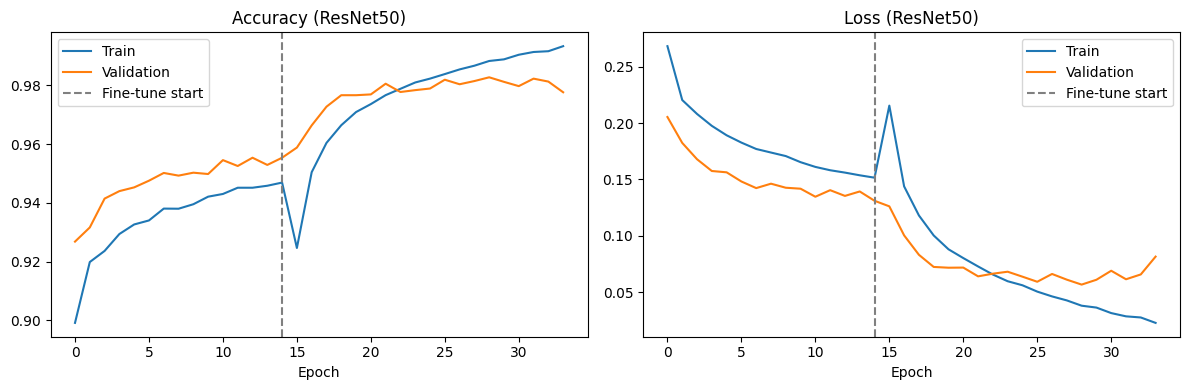

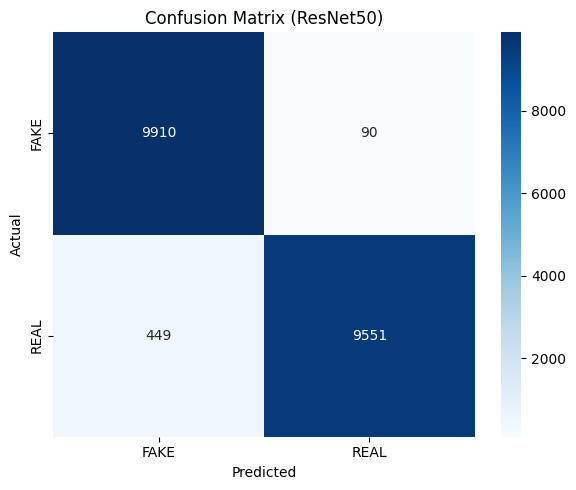

Model saved to /content/drive/MyDrive/Dissertation/cifake_resnet50_model.pth


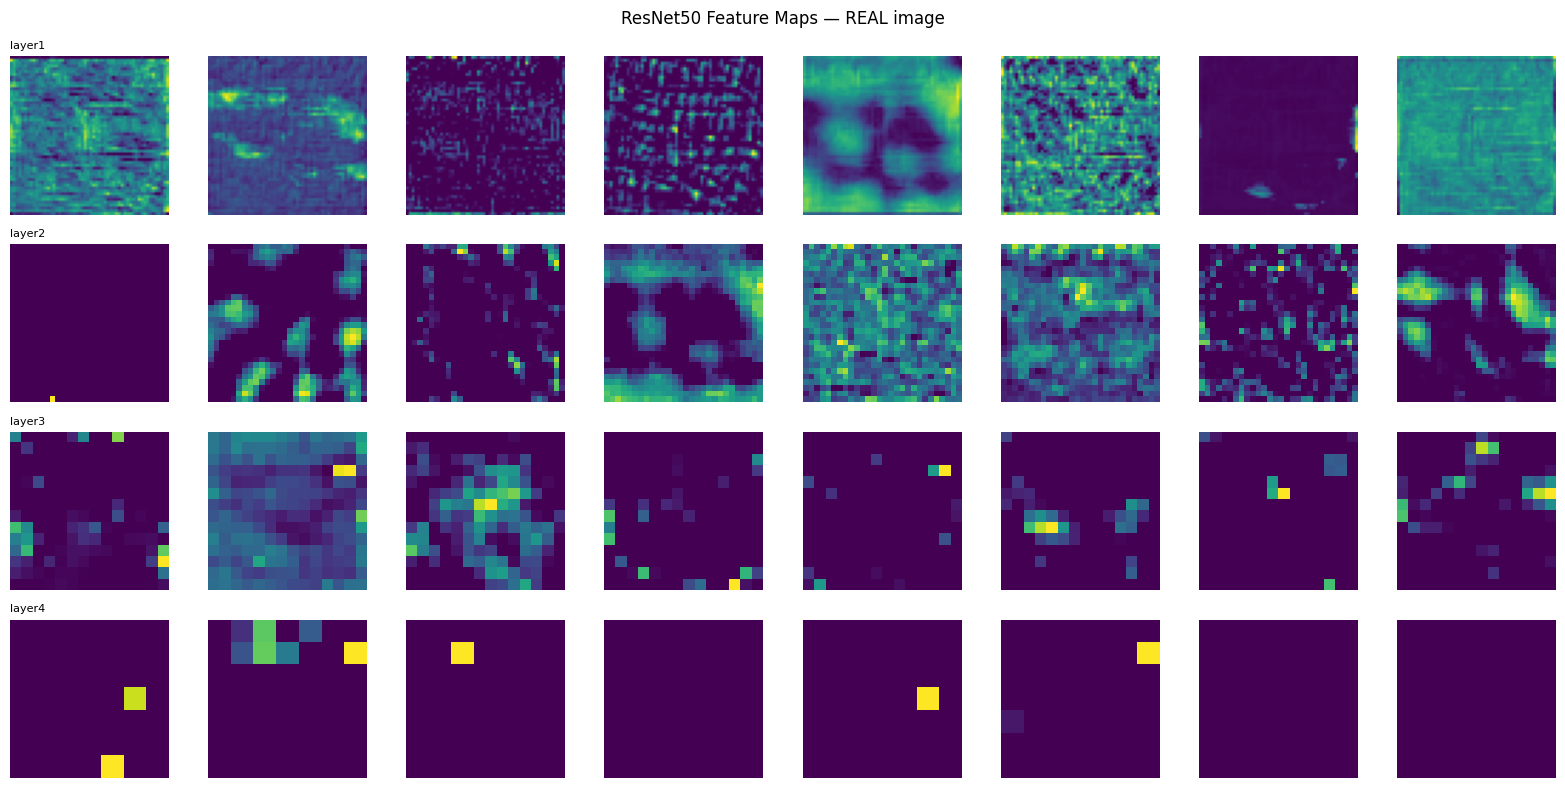

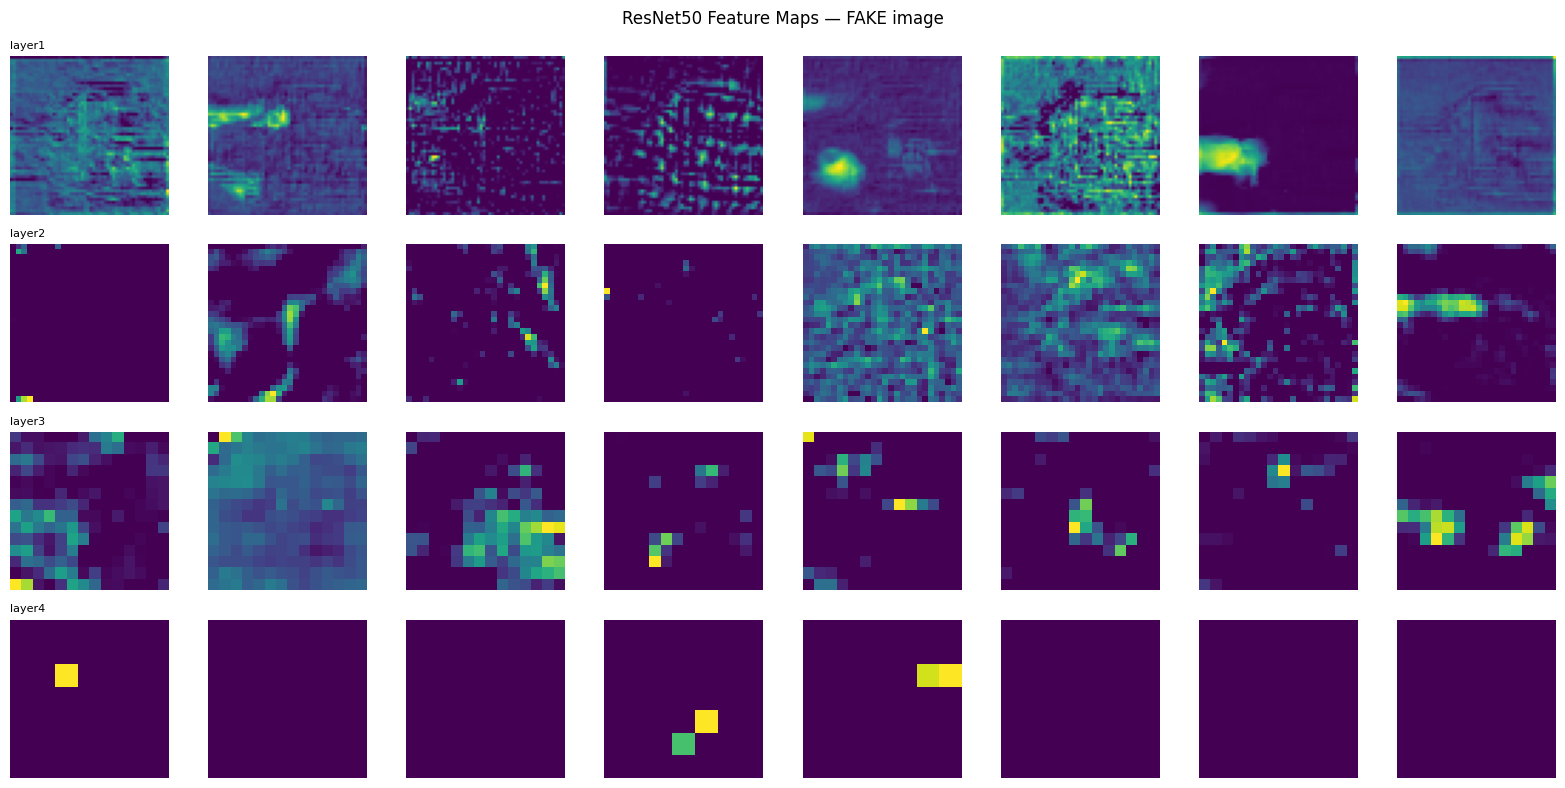

In [2]:
# Load Phase 2 checkpoint for evaluation
ckpt = torch.load(phase2_checkpoint_path, map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
history = ckpt["history"]
phase1_epochs = ckpt["phase1_epochs"]
phase2_epochs = ckpt["phase2_epochs"]
print(f"Loaded Phase 2 checkpoint ({phase2_epochs} epochs)")

# Evaluation
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images).squeeze(1)
        probs = torch.sigmoid(outputs).cpu().numpy()
        all_preds.extend(probs)
        all_labels.extend(labels.numpy())

y_true = np.array(all_labels)
y_pred_probs = np.array(all_preds)
y_pred = (y_pred_probs > 0.5).astype(int)

test_acc = (y_pred == y_true).mean()
print(f"\nTest Accuracy: {test_acc:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["FAKE", "REAL"]))

# Plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["accuracy"], label="Train")
axes[0].plot(history["val_accuracy"], label="Validation")
axes[0].axvline(x=phase1_epochs - 1, color="gray", linestyle="--", label="Fine-tune start")
axes[0].set_title("Accuracy (ResNet50)")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["loss"], label="Train")
axes[1].plot(history["val_loss"], label="Validation")
axes[1].axvline(x=phase1_epochs - 1, color="gray", linestyle="--", label="Fine-tune start")
axes[1].set_title("Loss (ResNet50)")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig("resnet50_training_history.png", dpi=150)
plt.show()

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["FAKE", "REAL"], yticklabels=["FAKE", "REAL"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (ResNet50)")
plt.tight_layout()
plt.savefig("resnet50_confusion_matrix.png", dpi=150)
plt.show()

# Save Final Model
save_path = os.path.join(save_dir, "cifake_resnet50_model.pth")
torch.save(model.state_dict(), save_path)
print(f"Model saved to {save_path}")

# Feature Map Visualisation
# Hooks capture each residual block's output so learned features can be inspected directly


def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (tensor.cpu() * std + mean).clamp(0, 1)


# One REAL and one FAKE test image so activations can be compared side by side
real_idx = next(i for i, (_, label) in enumerate(test_dataset.samples) if label == 1)
fake_idx = next(i for i, (_, label) in enumerate(test_dataset.samples) if label == 0)
sample_images = {
    "REAL": test_dataset[real_idx][0].unsqueeze(0).to(DEVICE),
    "FAKE": test_dataset[fake_idx][0].unsqueeze(0).to(DEVICE),
}

feature_maps = {}


def make_hook(name):
    def hook(module, input, output):
        feature_maps[name] = output.detach().cpu()
    return hook


resnet_blocks = ["layer1", "layer2", "layer3", "layer4"]
hooks = [getattr(model, name).register_forward_hook(make_hook(name)) for name in resnet_blocks]

model.eval()
for label, img in sample_images.items():
    feature_maps.clear()
    with torch.no_grad():
        model(img)

    fig, axes = plt.subplots(len(resnet_blocks), 8, figsize=(16, 2 * len(resnet_blocks)))
    for row, name in enumerate(resnet_blocks):
        fmap = feature_maps[name][0]  # (C, H, W)
        for col in range(8):
            axes[row, col].imshow(fmap[col].numpy(), cmap="viridis")
            axes[row, col].axis("off")
        axes[row, 0].set_title(name, fontsize=8, loc="left")

    fig.suptitle(f"ResNet50 Feature Maps — {label} image")
    plt.tight_layout()
    plt.savefig(f"resnet50_feature_maps_{label.lower()}.png", dpi=150)
    plt.show()

for h in hooks:
    h.remove()